# AGHRI 3D Early Camera–LiDAR Fusion Benchmark

This notebook summarises the selected AGHRI camera-LiDAR fusion figures and tables. The figures shown here are the selected saved figures from `results/aghri_fusion_paper_assets/selected_notebook_assets`.


## Methods Compared

The fusion framework is the same in both rows below. The comparison changes the 2D person detector checkpoint.

| Method name in figures | Detector checkpoint | Fusion method | Explanation |
|---|---|---|---|
| `Generic YOLO11s` | Public YOLO11s checkpoint | Legacy camera-guided LiDAR box association | Baseline detector used without AGHRI-specific fine-tuning. |
| `AGHRI fine-tuned YOLO11s` | YOLO11s fine-tuned on AGHRI ZED RGB data | Legacy camera-guided LiDAR box association | Detector adapted to the AGHRI viewpoints, outdoor scenes, person scale, and clothing/occlusion patterns. |

The important control is that the LiDAR association logic is not changed between these two detector rows. This keeps the comparison focused on whether better 2D detections improve downstream fused 3D person localization.


## Metrics Used

The accuracy and reliability metrics come from the offline frozen fusion evaluator. FPS is measured separately as mean live ROS 2 output throughput from `/camera_lidar_fusion/result` across the six held-out AGHRI test bags with RViz disabled.

| metric | definition | unit |
| --- | --- | --- |
| valid fusion rate | matched valid fused detections divided by detector person detections | ratio |
| mean/median/P95 3D error | Euclidean error between fused person centre and GT 3D person centre | metres |
| error > 1m | fraction of matched valid fused detections with 3D error above 1 metre | ratio |
| FPS | mean live ROS output rate on /camera_lidar_fusion/result across the six held-out AGHRI test bags | frames/s |


## Test Data Used

The frozen held-out benchmark uses all six official AGHRI test recordings.

| Test recording | Scenario | Robot motion |
|---|---|---|
| `footpath1_p1_nj+mk+gl_1walk+check_mv_11_12_2024_1_label` | Footpath | Moving |
| `footpath1_p1_oj+mk+gl_1walk+check_st_11_12_2024_1_label` | Footpath | Stationary |
| `in_straw_3pick_diff_st_10_24_2024_5_a_label` | Polytunnel | Stationary |
| `out_straw_1push_1walk_1swap_st_11_07_2024_1_b_label` | Polytunnel/outdoor straw | Stationary |
| `out_vine_1push_3carry_st_ly_11_06_2024_1_label` | Vineyard | Stationary |
| `out_vine_4swap+walk_st_ly_11_06_2024_2_label` | Vineyard | Stationary |

The overall result table, Figure 2, Figure 4a, and Figure 4b use all six recordings. Figure 3 uses one selected bag per scenario only, so that figure should not be confused with the full six-recording aggregate.


## Main Results Table

| model | detections | matched | valid_rate | mean_m | median_m | p95_m | err_gt_1m | fps |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Generic YOLO11s | 2787 | 2561 | 0.9218 | 0.4765 | 0.2038 | 1.8703 | 0.0859 | 15.15 |
| AGHRI fine-tuned | 2534 | 2433 | 0.9680 | 0.3926 | 0.1911 | 1.3595 | 0.0748 | 15.19 |

**Key observation.** The AGHRI fine-tuned detector improves the fusion output even though the LiDAR association method is kept fixed. Compared with generic YOLO11s, mean 3D error drops from 0.4765 m to 0.3926 m, P95 error drops from 1.8703 m to 1.3595 m, and valid fusion rate increases from 0.9218 to 0.9680. The all-six-bag live ROS output rate remains very similar between the two early-fusion checkpoints: 15.15 FPS for generic YOLO11s and 15.19 FPS for the AGHRI fine-tuned checkpoint.


In [ ]:
# Optional reproducibility cell: show where the selected assets live.
from pathlib import Path

ASSETS = Path("/home/prabuddhi/Desktop/Early_Fus/results/aghri_fusion_paper_assets/selected_notebook_assets")
print(ASSETS)
print("selected asset files:", len(list(ASSETS.rglob("*"))))


## Figure 1: Early Camera-LiDAR Human Detection Fusion Flow

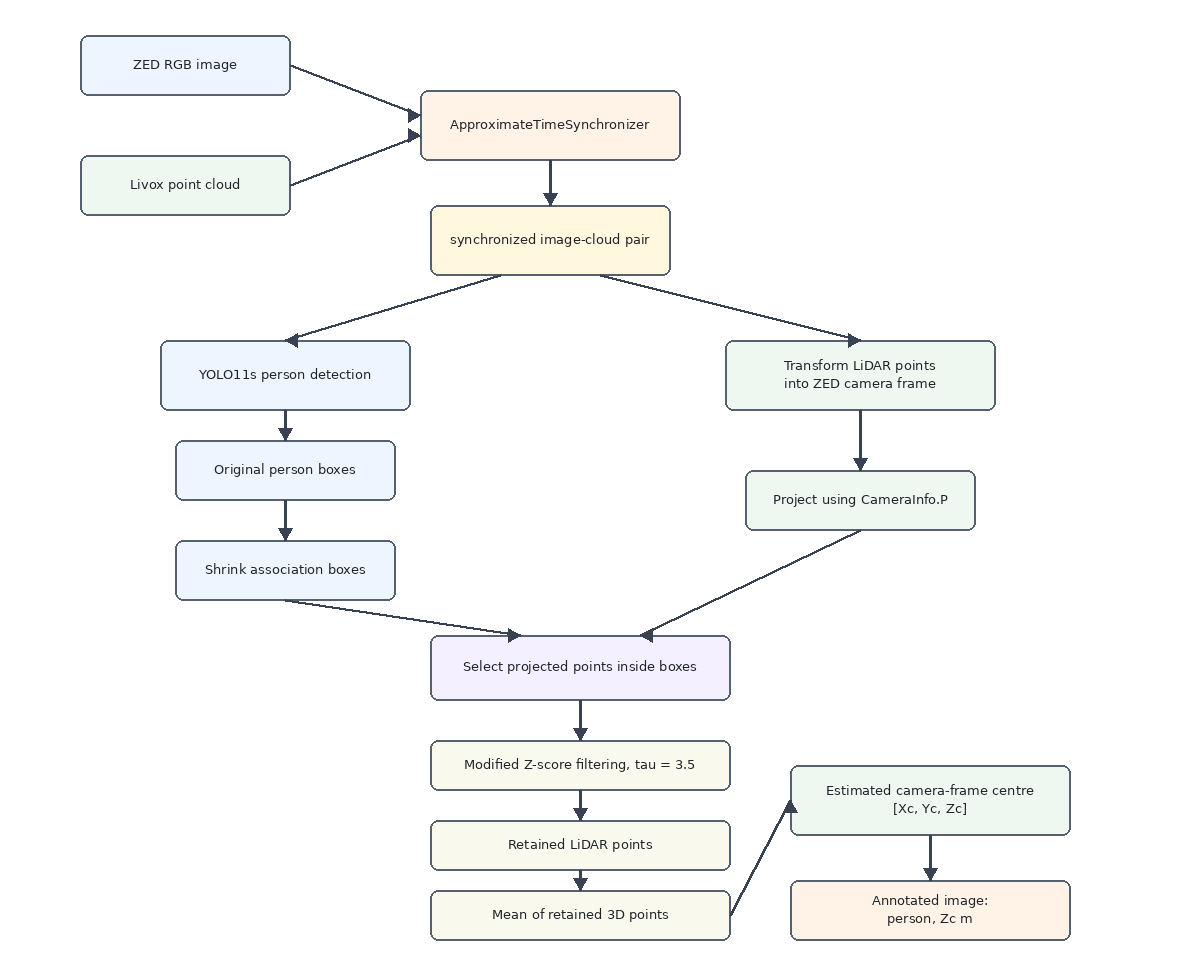

The runtime first synchronizes the ZED RGB image and Livox point cloud with an approximate-time synchronizer. YOLO11s produces person boxes on the synchronized image. In parallel, the point cloud is transformed into the ZED camera frame and projected into image coordinates using `CameraInfo.P`. The projected points inside the shrunken person association boxes become candidates. Modified Z-score filtering with `tau = 3.5` removes outliers, and the retained 3D points are averaged to estimate the camera-frame person centre `[Xc, Yc, Zc]`. The ROS playback overlay displays the forward camera depth `Zc` and horizontal camera offset `Xc`.


## Figure 2: Overall Test Summary

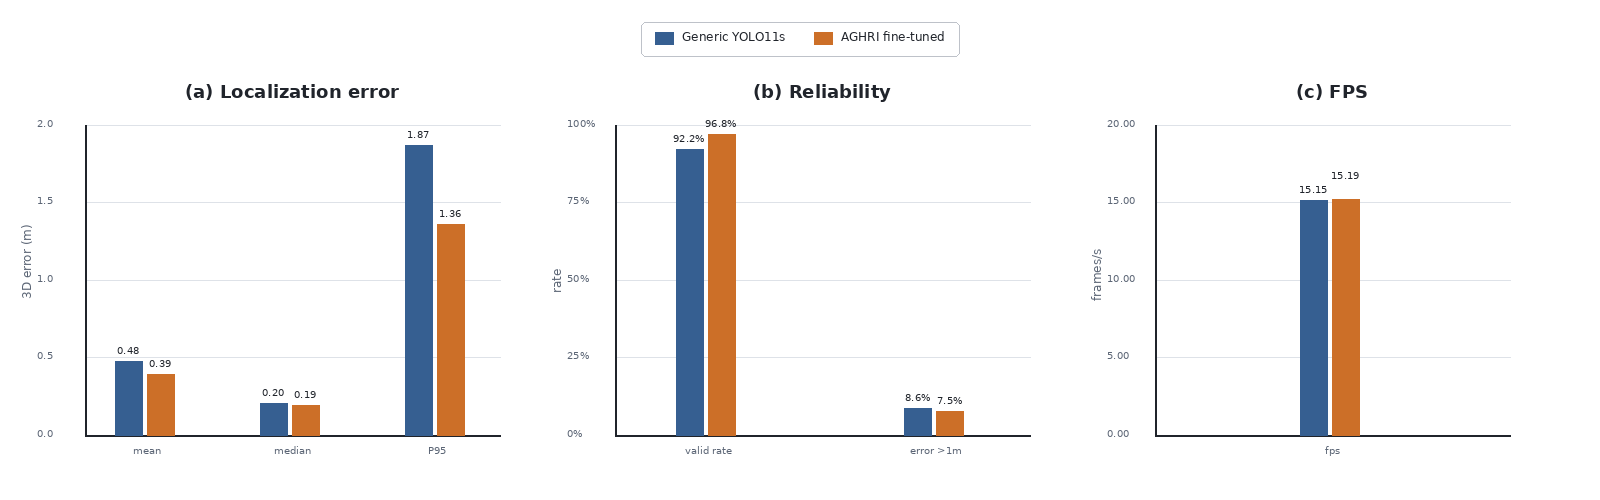

This combined figure places the three core summaries in one row. The localization-error panel shows that the fine-tuned detector reduces mean, median, and P95 3D localization error. The reliability panel shows a higher valid fusion rate and a lower fraction of errors above 1 m. The FPS panel shows that both checkpoints run at similar live ROS output rates.


## Figure 3: Representative Scenario Mean Error

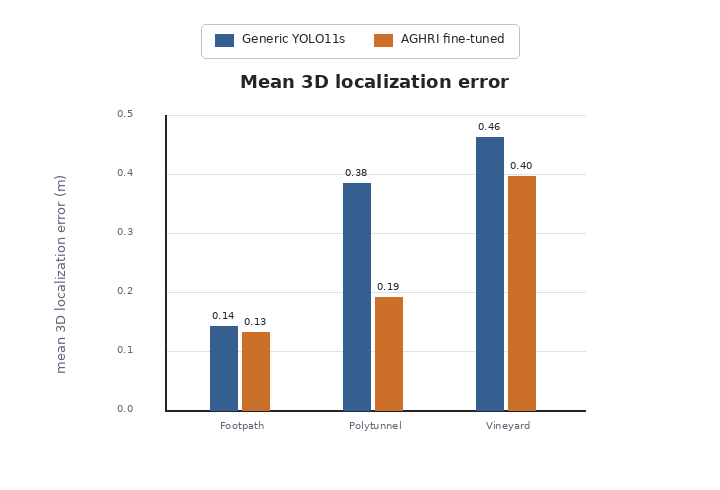

This figure is a compact scenario-level view. It uses one selected representative bag per scenario rather than all six test bags:

| Scenario | Selected bag used in this figure |
|---|---|
| Footpath | `footpath1_p1_oj+mk+gl_1walk+check_st_11_12_2024_1_label` |
| Polytunnel | `in_straw_3pick_diff_st_10_24_2024_5_a_label` |
| Vineyard | `out_vine_4swap+walk_st_ly_11_06_2024_2_label` |

The trend is consistent with the full aggregate: the AGHRI fine-tuned detector gives lower mean 3D error in the selected representative bags.


## Figure 4a: Depth-normalized 3D localization error by distance band

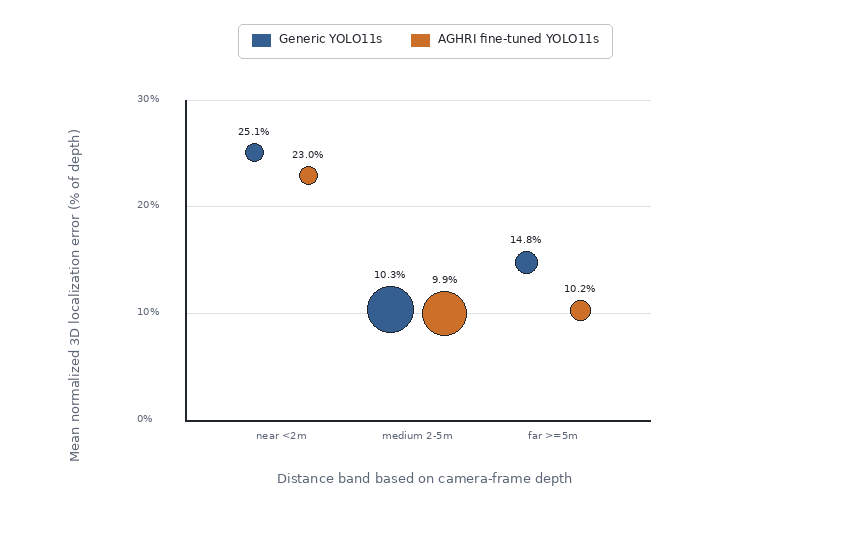

This figure reports a depth-normalized error: for each valid matched detection, the 3D localization error is divided by the camera-frame depth before averaging within the near, medium, and far bands. Point position shows how large the mean normalized error is within each distance band. Point size shows how much data supports that value, because larger points represent more valid matched detections. Under this normalized view, the AGHRI fine-tuned detector remains lower than generic YOLO11s in all three bands, with the largest relative reduction in the far range.


## Figure 4b: ZED Depth Image Consistency

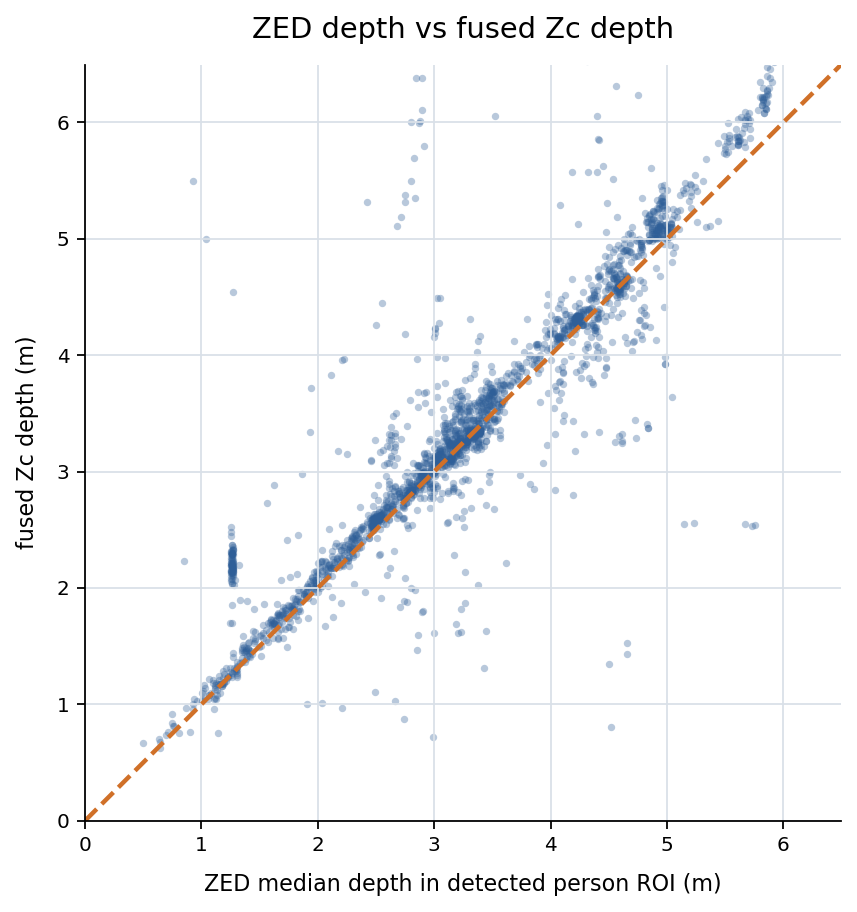

This scatter plot compares the robust ZED depth image reference inside the detected person region with the fused camera-frame `Zc` depth estimated from the LiDAR association output. It is a visual agreement check rather than an absolute 3D localization benchmark, because the ZED depth maps provide surface depth values, not annotated 3D person centres. Points close to the dashed diagonal line indicate good Z-depth agreement. Points above the line mean the fused `Zc` is larger or farther than the ZED depth, while points below the line mean the fused `Zc` is smaller or closer than the ZED depth.

Across this ZED-depth consistency set, the fused LiDAR `Zc` differed from the ZED depth by a median absolute error of 0.1169 m, corresponding to a median relative absolute Z-depth error of 3.96%.


## Figure 5: YOLO11s Fine-tuning Curves

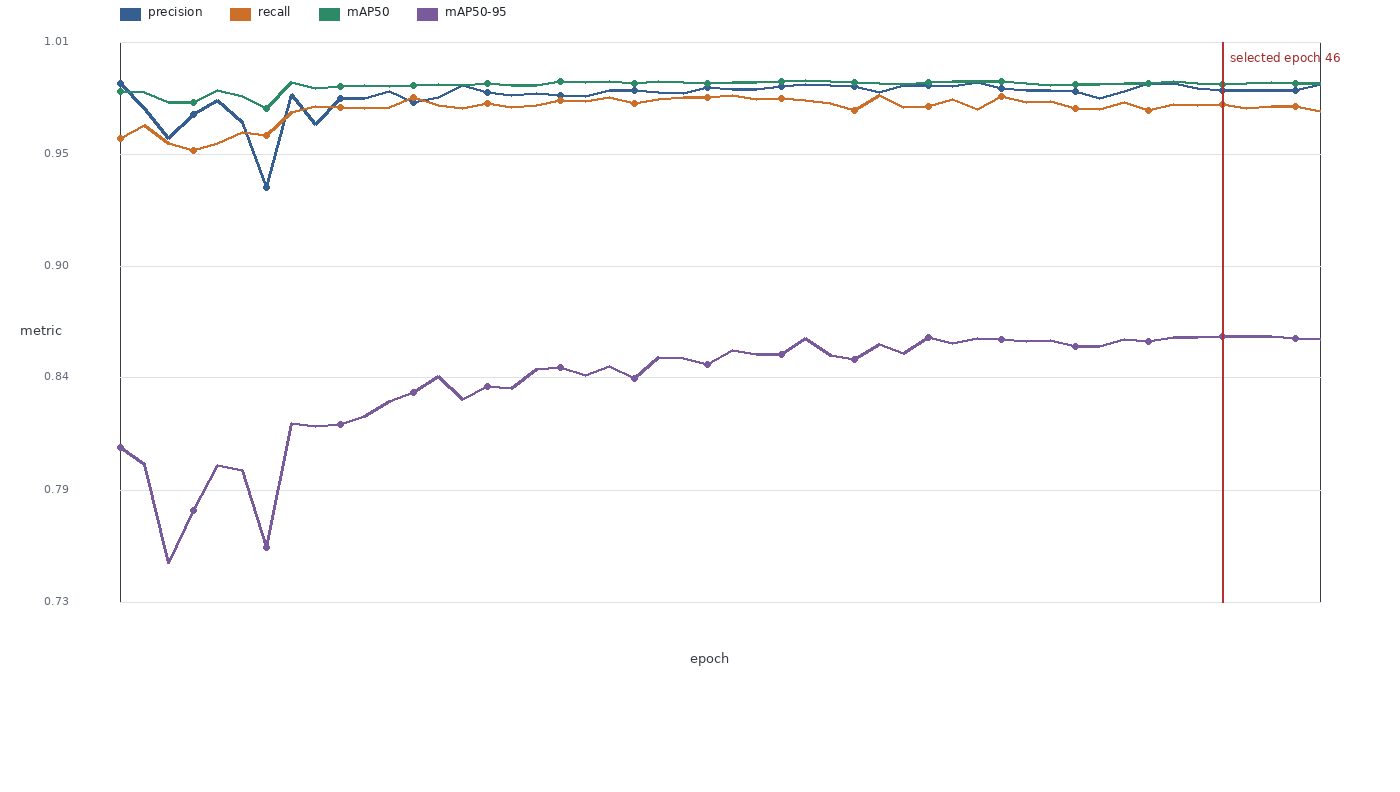

The above curve shows the cluster fine-tuning run used to adapt YOLO11s to AGHRI ZED RGB images. The curves track validation precision, recall, mAP50, and mAP50-95 over training epochs. Epoch 46 is marked as the selected best checkpoint. That checkpoint is then used in the frozen fusion comparison, so the downstream results measure how an AGHRI-adapted 2D detector changes the final fused 3D person localization.


## Figure 6: Step-by-step LiDAR Association Example

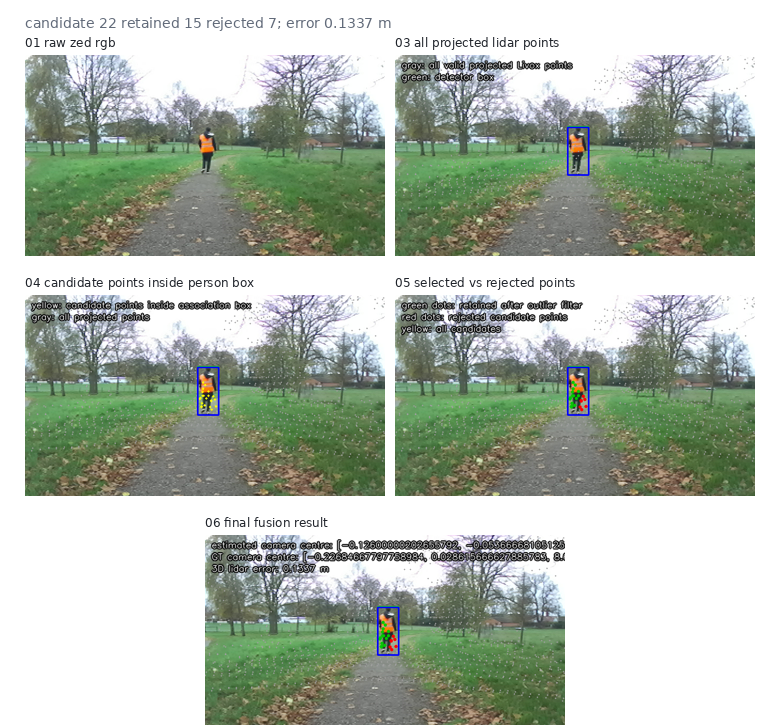

The raw ZED image first shows the target person. The projected-point panel then shows all LiDAR points that land inside the image. The candidate panel isolates the points inside the shrunken person association box. The selected-vs-rejected panel shows the modified Z-score filter in action: 22 candidate points enter the filter, 15 are retained, and 7 are rejected. The final panel averages the retained 3D points and recomputes a LiDAR-centre error of about 0.1337 m.


## ROS Topics and Frames

| topic | type | frame |
| --- | --- | --- |
| /dataset/cam_zed_rgb/image | sensor_msgs/Image | front_left_camera_optical_frame |
| /dataset/lidar/points | sensor_msgs/PointCloud2 | front_lidar_link |
| /dataset/cam_zed_rgb/camera_info | sensor_msgs/CameraInfo | front_left_camera_optical_frame |
| /dataset/cam_fish_front/camera_info | sensor_msgs/CameraInfo | fish_front_camera_link_optical |
| /dataset/cam_fish_left/camera_info | sensor_msgs/CameraInfo | fish_left_camera_link_optical |
| /dataset/cam_fish_right/camera_info | sensor_msgs/CameraInfo | fish_right_camera_link_optical |
| /tf | tf2_msgs/TFMessage | map -> base_link |
| /tf_static | tf2_msgs/TFMessage | static sensor tree |

The all-topic ROS 2 bags contain the ZED RGB image and CameraInfo, three fisheye CameraInfo streams, Livox point clouds, `/tf`, and `/tf_static`. The fusion node only needs the ZED RGB stream, ZED CameraInfo, Livox cloud, and TF chain for the published ZED RGB-Livox result.


## Figure 7: ROS Playback Qualitative Example

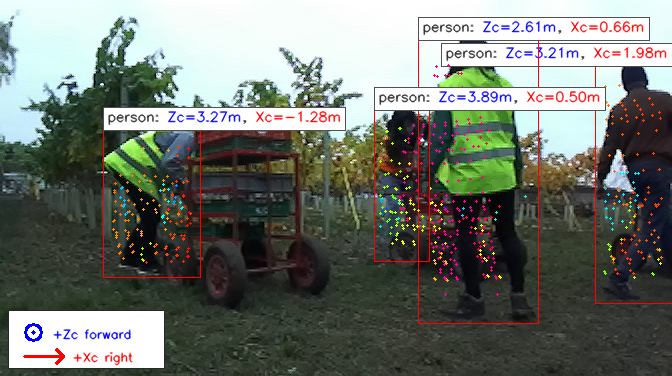

This image was captured directly from the ROS 2 playback output topic `/camera_lidar_fusion/result` while playing `out_vine_4swap+walk_st_ly_11_06_2024_2_label`. It shows the fine-tuned YOLO11s detections, projected Livox points over the ZED RGB image, and the displayed fused camera-frame centre labels. In each label, blue `Zc` is the forward camera depth and red `Xc` is the horizontal offset, matching the small legend in the image. Height `Yc` is intentionally not shown.


## Figure 8: No Valid Fusion Failure

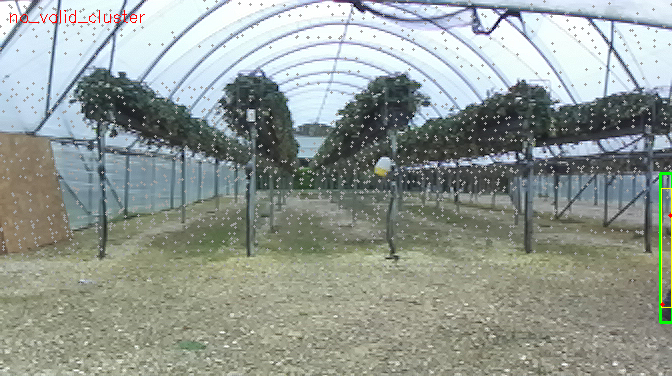

This example shows a no valid fusion failure where projected LiDAR candidate points are present for the detection, but they do not survive the association and filtering logic. The candidate set is too weak or inconsistent to meet the configured association criteria, so no retained point cluster is accepted and the pipeline does not report a fused 3D person centre for this box.


## Summary

Across the frozen AGHRI fusion benchmark, AGHRI fine-tuning improves the detector input to the same LiDAR association pipeline. The main quantitative effect is lower 3D localization error and higher valid fusion rate.
